# EDA and Machine Learning — вступительное задание ИТМО «Искусственный интеллект»

Уровень **C** (продвинутый): вопросы **C1–C5**.

Ноутбук воспроизводим сверху вниз: `Kernel → Restart & Run All`.
Данные читаются только из локальных файлов `data/complaints_train.csv`, `data/complaints_test.csv`,
`data/sample_submission.csv`. Оригинальные файлы не изменяются.

## Setup — общее окружение для всех заданий

Полный обучающий CSV — около 7.7 ГБ, поэтому он **никогда не загружается в pandas целиком**: все проходы по
нему выполняет DuckDB, а в память попадают только агрегаты и подготовленная таблица признаков.

Две технические особенности файла, обнаруженные при чтении:

- в поле `Consumer.Complaint.Narrative` есть переводы строки внутри значений, поэтому параллельный CSV-ридер
  DuckDB на этом файле падает — обучающий файл читается с `parallel=false`;
- вывод типов отключён (`all_varchar=true`): данные грязные, а даты записаны в трёх разных форматах,
  поэтому все поля читаются как строки и разбираются явно.

In [1]:
from __future__ import annotations

import hashlib
import re
import time
import warnings
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.calibration import calibration_curve
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
)

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


def find_root(markers=("uv.lock", "pyproject.toml")) -> Path:
    """Корень репозитория = ближайший каталог вверх от cwd, содержащий маркер.

    Так ноутбук работает одинаково и при запуске из notebooks/ (Jupyter Lab),
    и из корня (nbconvert), не завися от текущего рабочего каталога.
    """
    start = Path.cwd().resolve()
    for candidate in (start, *start.parents):
        if any((candidate / m).exists() for m in markers):
            return candidate
    raise RuntimeError(
        f"Корень репозитория не найден вверх от {start} (искали {markers})"
    )


ROOT = find_root()
DATA = ROOT / "data"
CACHE = ROOT / "cache"
CACHE.mkdir(exist_ok=True)
RESULTS = ROOT / "results"
RESULTS.mkdir(exist_ok=True)

TRAIN_CSV = DATA / "complaints_train.csv"
TEST_CSV = DATA / "complaints_test.csv"
SAMPLE_SUB = DATA / "sample_submission.csv"
SUBMISSION = RESULTS / "submission.csv"

con = duckdb.connect()
con.execute("SET threads=8")
con.execute("SET memory_limit='16GB'")
con.execute("SET preserve_insertion_order=false")

pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 40)

print("duckdb", duckdb.__version__, "| pandas", pd.__version__)
print("train csv GB:", round(TRAIN_CSV.stat().st_size / 1024 ** 3, 2))
print("test  csv GB:", round(TEST_CSV.stat().st_size / 1024 ** 3, 2))

duckdb 1.5.5 | pandas 3.0.5
train csv GB: 7.19
test  csv GB: 0.39


### Нормализация грязных значений и разбор дат

Ниже — единые SQL-макросы, которые используются во всех заданиях:

- `nrm(x)` — обрезка пробелов, схлопывание внутренних пробелов, приведение к верхнему регистру
  (лечит `" Postal mail "`, `GETTING A CREDIT CARD` / `Getting a credit card`);
- `cln(x)` — то же плюс превращение мусорных заглушек (`NA`, `N/A`, `null`, `-`, `.`, `unknown`, `none`)
  в настоящий `NULL`: это закодированный пропуск, а не отдельная категория;
- `pdate(x)` — разбор трёх форматов дат (`2024-01-31`, `31 Jan 2024`, `Jan 31, 2024`) через `try_strptime`;
  ошибки не «проглатываются» — доля неразобранных дат проверяется отдельно;
- `nnar(x)` — нормализация текста жалобы для поиска шаблонных подач (нижний регистр, цифры и пробелы
  схлопываются), используется в C5.

In [2]:
con.execute(r"""
create or replace macro nrm(x) as
    nullif(upper(regexp_replace(trim(coalesce(x, '')), '\s+', ' ', 'g')), '')
""")
con.execute(r"""
create or replace macro cln(x) as
    case when nrm(x) in ('NA','N/A','NULL','-','.','UNKNOWN','NONE') then null else nrm(x) end
""")
con.execute(r"""
create or replace macro pdate(x) as coalesce(
    try_strptime(trim(x), '%Y-%m-%d'),
    try_strptime(trim(x), '%d %b %Y'),
    try_strptime(trim(x), '%b %d, %Y')
)
""")
con.execute(r"""
create or replace macro nnar(x) as nullif(
    regexp_replace(regexp_replace(lower(trim(coalesce(x, ''))), '[0-9]+', ' ', 'g'), '\s+', ' ', 'g'),
    ''
)
""")


def train_src(cols: str = "*") -> str:
    # parallel=false: в narrative есть переводы строки внутри значений
    return f"(select {cols} from read_csv('{TRAIN_CSV.as_posix()}', all_varchar=true, header=true, parallel=false))"


def test_src(cols: str = "*") -> str:
    return f"(select {cols} from read_csv('{TEST_CSV.as_posix()}', all_varchar=true, header=true, parallel=true))"


print("macros ready")

macros ready


### Единственный тяжёлый проход по CSV: таблица признаков

Один проход по каждому файлу извлекает нормализованные табличные поля, разобранные даты, признаки наличия
и длины текста и хеш нормализованного текста (для C5). Результат кэшируется в Parquet, поэтому все
последующие вопросы работают с компактной таблицей, а 7.7 ГБ CSV больше не перечитывается.

Кэш — производный артефакт: он лежит в git-игнорируемой папке `cache/` и при отсутствии пересобирается
из исходных CSV, поэтому ноутбук остаётся воспроизводимым «с нуля».

In [3]:
FEATURE_SQL = """
              select complaint_id,
                     cln("Product")                                                          as product,
                     cln(sub_product)                                                        as sub_product,
                     cln("Issue")                                                            as issue,
                     cln("Sub.Issue")                                                        as sub_issue,
                     cln("Company")                                                          as company,
                     cln("State")                                                            as state,
                     cln("Submitted Via")                                                    as submitted_via,
                     cln(tags)                                                               as tags,
                     cast(pdate("Date received") as date)                                    as date_received,
                     cast(pdate(date_sent_to_company) as date)                               as date_sent,
                     case when cln("Consumer.Complaint.Narrative") is null then 0 else 1 end as has_text,
                     length(coalesce(cln("Consumer.Complaint.Narrative"), ''))               as text_len,
                     md5(nnar(cln("Consumer.Complaint.Narrative")))                          as nar_hash {extra}
              from {src} \
              """

TRAIN_FEAT = CACHE / "train_feat.parquet"
TEST_FEAT = CACHE / "test_feat.parquet"

if not TEST_FEAT.exists():
    t0 = time.time()
    q = FEATURE_SQL.format(extra="", src=test_src())
    con.execute(
        f"copy ({q}) to '{TEST_FEAT.as_posix()}' (format parquet, compression zstd)"
    )
    print(f"test features built in {time.time() - t0:.0f}s")

if not TRAIN_FEAT.exists():
    t0 = time.time()
    q = FEATURE_SQL.format(extra=", cast(relief_granted as int) as y", src=train_src())
    con.execute(
        f"copy ({q}) to '{TRAIN_FEAT.as_posix()}' (format parquet, compression zstd)"
    )
    print(
        f"train features built in {time.time() - t0:.0f}s (single pass over the 7.7 GB CSV)"
    )

TRAIN_P = TRAIN_FEAT.as_posix()
TEST_P = TEST_FEAT.as_posix()

overview = con.execute(f"""
select 'train' as part, count(*) as rows, count(distinct complaint_id) as uniq_ids,
       min(date_received) as first_date, max(date_received) as last_date,
       sum(case when date_received is null then 1 else 0 end) as unparsed_dates,
       round(avg(y), 4) as relief_rate
from '{TRAIN_P}'
union all
select 'test', count(*), count(distinct complaint_id),
       min(date_received), max(date_received),
       sum(case when date_received is null then 1 else 0 end), null
from '{TEST_P}'
""").df()
overview

,part,rows,uniq_ids,first_date,last_date,unparsed_dates,relief_rate
0,train,13367673,13238348,2019-10-21,2025-04-28,0.0,0.3982
1,test,1205944,1205944,2025-02-19,2025-05-18,0.0,NaN


Обучающая часть покрывает период до февраля 2025 включительно, отложенная — февраль–май 2025:
**test действительно является будущим относительно train**, и это определяет схему валидации в C2.
Неразобранных дат нет, то есть три формата покрывают все значения.

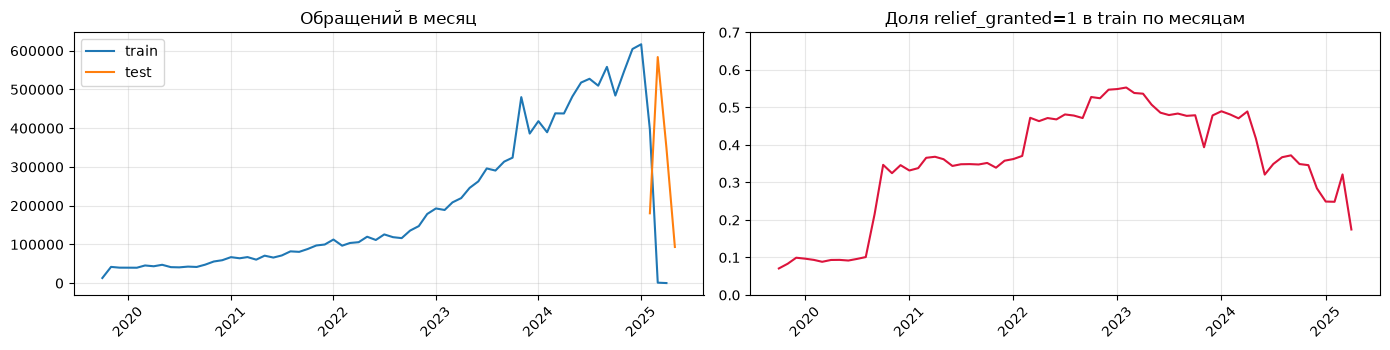

     month      n  relief_rate
2024-09-01 558255     0.372158
2024-10-01 484233     0.349010
2024-11-01 546662     0.346066
2024-12-01 604385     0.284289
2025-01-01 616602     0.249062
2025-02-01 396592     0.248422
2025-03-01   1251     0.321343
2025-04-01    252     0.174603

     month      n
2025-02-01 180320
2025-03-01 583608
2025-04-01 348638
2025-05-01  93378


In [4]:
monthly = con.execute(f"""
select date_trunc('month', date_received) as month, count(*) as n, avg(y) as relief_rate
from '{TRAIN_P}' group by 1 order by 1
""").df()
monthly_test = con.execute(f"""
select date_trunc('month', date_received) as month, count(*) as n
from '{TEST_P}' group by 1 order by 1
""").df()

fig, ax = plt.subplots(1, 2, figsize=(14, 3.6))
ax[0].plot(monthly["month"], monthly["n"], label="train")
ax[0].plot(monthly_test["month"], monthly_test["n"], label="test")
ax[0].set_title("Обращений в месяц")
ax[0].legend()
ax[1].plot(monthly["month"], monthly["relief_rate"], color="crimson")
ax[1].set_title("Доля relief_granted=1 в train по месяцам")
ax[1].set_ylim(0, 0.7)
for a in ax:
    a.grid(alpha=0.3)
    a.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

print(monthly.tail(8).to_string(index=False))
print()
print(monthly_test.to_string(index=False))

**Важное наблюдение для всех заданий уровня C:** доля целевого класса нестационарна — она поднималась до
~0.55 в начале 2023 года и падает до ~0.25 к февралю 2025. Модель, обученная на всей истории с равным
весом, будет систематически переоценивать вероятность компенсации на отложенной выборке. Поэтому
валидация обязательно временная (C2), а обучающее окно ограничено недавним периодом.

## C1 — Модель риска на отложенной выборке

**Задание**

Модель риска на отложенной выборке
Постройте модель предсказания вероятности relief_granted по complaints_train.csv и сделайте предсказания для всех
строк complaints_test.csv. Базовые табличные признаки: Product, sub_product, Issue, Sub.Issue, Company, State,
Submitted Via, tags. Модель — любая. Приложите CSV с колонками complaint_id, relief_proba в формате
sample_submission.csv; relief_proba — вероятность в диапазоне [0, 1], не бинарная метка. Основная метрика — PR-AUC
(average precision).

Отдельно ответьте: какие из выданных колонок вы исключили из признаков и почему? Часть полей заполняется уже после
разбора обращения — их использование даст отличную локальную метрику и бесполезную модель.

*Формат ответа C1: текстовый ответ не требуется. Должен сгенерироваться файл submission.csv, в дальнейшем он будет
загружен в качестве ответа.*

### C1.1 Отбор колонок: проверка полей на утечку

Прежде чем строить модель, проверяем каждую **выданную** колонку на то, доступна ли она в момент предсказания.
Признак «отличная локальная метрика и бесполезная модель» — это поле, заполняемое уже после разбора обращения.
Проверяем это данными: считаем долю `relief_granted=1` по значениям подозрительных полей.

In [5]:
leak_checks = {}

leak_checks["company_public_response"] = con.execute(f"""
select cln(company_public_response) as value, count(*) as n,
       round(avg(cast(relief_granted as int)), 4) as relief_rate
from {train_src()} group by 1 order by n desc
""").df()

leak_checks["timely_response"] = con.execute(f"""
select cln(timely_response) as value, count(*) as n,
       round(avg(cast(relief_granted as int)), 4) as relief_rate
from {train_src()} group by 1 order by n desc
""").df()

leak_checks["internal_priority_score"] = con.execute(f"""
select case when try_cast(internal_priority_score as int) < 40 then 'score < 40'
            when try_cast(internal_priority_score as int) < 60 then 'score 40..59'
            when try_cast(internal_priority_score as int) is null then 'unparsed/null'
            else 'score >= 60' end as value,
       count(*) as n, round(avg(cast(relief_granted as int)), 4) as relief_rate
from {train_src()} group by 1 order by n desc
""").df()

leak_checks["consumer_consent_region"] = con.execute(f"""
select count(*) as n, count(consumer_consent_region) as non_null_raw,
       count(cln(consumer_consent_region)) as non_null_cleaned
from {train_src()}
""").df()

for name, frame in leak_checks.items():
    print(f"--- {name} ---")
    print(frame.head(12).to_string(index=False, max_colwidth=90))
    print()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

--- company_public_response ---
                                                                                     value       n  relief_rate
COMPANY BELIEVES COMPLAINT CAUSED PRINCIPALLY BY ACTIONS OF THIRD PARTY OUTSIDE THE CON... 7693215       0.3895
                                                                                       NaN 5485723       0.4196
                                     COMPANY DISPUTES THE FACTS PRESENTED IN THE COMPLAINT  150515       0.1414
                                COMPANY CAN'T VERIFY OR DISPUTE THE FACTS IN THE COMPLAINT    9941       0.0778
                  COMPANY BELIEVES COMPLAINT RELATES TO A DISCONTINUED POLICY OR PROCEDURE    7520       0.0662
COMPANY HAS RESPONDED TO THE CONSUMER AND THE CFPB AND CHOOSES NOT TO PROVIDE A PUBLIC ...    6820       0.0526
                        COMPANY BELIEVES THE COMPLAINT IS THE RESULT OF A MISUNDERSTANDING    4580       0.0310
COMPANY BELIEVES COMPLAINT REPRESENTS AN OPPORTUNITY FOR IMPROVEMENT TO 

Результат проверки:

- **`internal_priority_score`** — синтетический пост-фактум скор: при значении `< 40` компенсация встречается
  в ~3% случаев, при `>= 60` — в ~93%. Внутри каждой из этих зон значение почти не влияет на исход, то есть поле
  фактически кодирует уже известный результат разбора. Это главный «капкан» задания.
- **`company_public_response`** — публичный ответ компании: он формулируется **после** разбора обращения
  (`Company disputes the facts` → 14% компенсаций против 42% у пустого значения).
- **`timely_response`** — признак того, что компания ответила в срок; известен только после ответа.
- **`consumer_consent_region`** — колонка пуста на 100% (нет ни одного непустого значения), информации не несёт.

Исключаются также `complaint_id` (идентификатор, 13.2 млн уникальных значений — чистый шум/переобучение) и
`ZIP code` (30 651 значение, при этом ZIP не согласован со `State` — см. рассуждение ниже; в списке базовых
признаков C1 его нет).

`Consumer.Complaint.Narrative` в C1 **не используется** — это отдельный вопрос C4, где прирост от текста
измеряется на той же схеме валидации.

In [6]:
# date_sent_to_company: доступна в момент предсказания (передача в компанию происходит на приёме,
# до разбора), поэтому лаг проверяем как допустимый признак, но в базовый набор C1 не включаем —
# условие C1 задаёт ровно 8 табличных полей.
lag_check = con.execute(f"""
select date_diff('day', date_received, date_sent) as lag_days, count(*) as n, round(avg(y), 4) as relief_rate
from '{TRAIN_P}'
where date_received is not null and date_sent is not null
group by 1 order by n desc limit 8
""").df()
print(lag_check.to_string(index=False))

FEATURES_CAT = [
    "product",
    "sub_product",
    "issue",
    "sub_issue",
    "state",
    "submitted_via",
    "tags",
]
FEATURE_HIGH_CARD = "company"

card = (
    con.execute(f"""
select
    count(distinct product) as product, count(distinct sub_product) as sub_product,
    count(distinct issue) as issue, count(distinct sub_issue) as sub_issue,
    count(distinct state) as state, count(distinct submitted_via) as submitted_via,
    count(distinct tags) as tags, count(distinct company) as company
from '{TRAIN_P}'
""")
    .df()
    .T.rename(columns={0: "n_unique_after_cleaning"})
)
card

 lag_days        n  relief_rate
        0 12676682       0.4032
        1   250314       0.3454
       -1    94304       0.4044
        7    51222       0.4220
        6    38381       0.3802
        2    36227       0.2472
        3    17368       0.2122
        5    14345       0.2335


,n_unique_after_cleaning
product,14
sub_product,58
issue,94
sub_issue,217
state,67
submitted_via,6
tags,3
company,5311


После нормализации число уровней резко падает (например `Submitted Via` — с 21 «сырого» варианта до 6,
`Product` — с 56 до 14): разнобой в регистре и пробелах был искусственным. Все категориальные признаки кроме
`Company` имеют ≤ 255 уровней и кодируются как нативные категории градиентного бустинга; `Company`
(≈5.3 тыс. уровней) требует отдельного кодирования — см. C1.2.

### C1.2 Обучающее окно, кодирование и модель

Разбиение — **временное** (подробное обоснование в C2): последние три месяца train
(`2024-12-01 … 2025-02-28`) отложены под локальную валидацию, модель учится на предшествующем окне.
Обучающее окно ограничено 2024 годом: доля компенсаций нестационарна (0.55 в начале 2023 → 0.25 к февралю 2025),
и старые месяцы смещают уровень вероятностей вверх.

`Company` кодируется **target encoding с out-of-fold схемой внутри обучающего окна** (5 фолдов, сглаживание к
общему среднему обучающего окна) плюс частотой. Никакая статистика не считается по валидации или по test —
это защита от preprocessing-утечки.

In [7]:
FIT_START = "2024-01-01"
VALID_START = "2024-12-01"

cols = ", ".join(FEATURES_CAT + [FEATURE_HIGH_CARD, "date_received", "has_text", "y"])
frame = con.execute(f"""
select {cols} from '{TRAIN_P}'
where date_received >= date '{FIT_START}' and date_received is not null
""").df()
frame["date_received"] = pd.to_datetime(frame["date_received"])
# строковые поля -> category: окно с 2024 года это несколько миллионов строк
for c in FEATURES_CAT + [FEATURE_HIGH_CARD]:
    frame[c] = frame[c].astype("category")
print(
    f"загружено {len(frame):,} строк, память {frame.memory_usage(deep=True).sum() / 1024 ** 2:.0f} МБ"
)

valid_mask = frame["date_received"] >= pd.Timestamp(VALID_START)
fit_df = frame.loc[~valid_mask].reset_index(drop=True)
val_df = frame.loc[valid_mask].reset_index(drop=True)

print(
    f"fit   {fit_df.shape[0]:>9,} rows  {fit_df.date_received.min().date()} .. {fit_df.date_received.max().date()}  "
    f"relief_rate={fit_df.y.mean():.4f}"
)
print(
    f"valid {val_df.shape[0]:>9,} rows  {val_df.date_received.min().date()} .. {val_df.date_received.max().date()}  "
    f"relief_rate={val_df.y.mean():.4f}"
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

загружено 6,929,061 строк, память 172 МБ


fit   5,309,979 rows  2024-01-01 .. 2024-11-30  relief_rate=0.3987
valid 1,619,082 rows  2024-12-01 .. 2025-04-28  relief_rate=0.2621


In [8]:
def fit_category_maps(df: pd.DataFrame, cols: list[str]) -> dict[str, dict]:
    """Уровни категорий берутся ТОЛЬКО из обучающей части."""
    return {
        c: {v: i for i, v in enumerate(sorted(df[c].dropna().unique()))} for c in cols
    }


def apply_category_maps(df: pd.DataFrame, maps: dict[str, dict]) -> pd.DataFrame:
    out = pd.DataFrame(index=df.index)
    for c, m in maps.items():
        out[c] = (
            df[c].map(m).astype("float64")
        )  # неизвестные уровни -> NaN (нативно поддержано HGB)
    return out


def oof_target_encoding(
        fit_df: pd.DataFrame,
        col: str,
        n_splits: int = 5,
        smoothing: float = 50.0,
        seed: int = RANDOM_STATE,
) -> tuple[pd.Series, pd.Series, float, pd.Series]:
    """OOF target encoding внутри обучающего окна + полная карта для применения к будущему."""
    rng = np.random.default_rng(seed)
    fold = rng.integers(0, n_splits, size=len(fit_df))
    prior = fit_df["y"].mean()
    oof = np.full(len(fit_df), np.nan)
    for f in range(n_splits):
        in_fold = fold == f
        part = fit_df.loc[~in_fold]
        agg = part.groupby(col, observed=True)["y"].agg(["sum", "count"])
        enc = (agg["sum"] + prior * smoothing) / (agg["count"] + smoothing)
        oof[in_fold] = fit_df.loc[in_fold, col].map(enc).to_numpy(dtype="float64")
    oof = np.where(np.isnan(oof), prior, oof)

    agg_full = fit_df.groupby(col, observed=True)["y"].agg(["sum", "count"])
    full_map = (agg_full["sum"] + prior * smoothing) / (agg_full["count"] + smoothing)
    freq_map = np.log1p(agg_full["count"])
    return pd.Series(oof, index=fit_df.index), full_map, prior, freq_map


def build_matrix(
        df: pd.DataFrame,
        maps: dict[str, dict],
        te_map: pd.Series,
        prior: float,
        freq_map: pd.Series,
        te_values: pd.Series | None = None,
) -> pd.DataFrame:
    X = apply_category_maps(df, maps)
    if te_values is not None:
        X["company_te"] = te_values.to_numpy()
    else:
        X["company_te"] = df[FEATURE_HIGH_CARD].map(te_map).fillna(prior).to_numpy()
    X["company_freq"] = df[FEATURE_HIGH_CARD].map(freq_map).fillna(0.0).to_numpy()
    return X


cat_maps = fit_category_maps(fit_df, FEATURES_CAT)
te_oof, te_map, te_prior, freq_map = oof_target_encoding(fit_df, FEATURE_HIGH_CARD)

X_fit = build_matrix(fit_df, cat_maps, te_map, te_prior, freq_map, te_values=te_oof)
X_val = build_matrix(val_df, cat_maps, te_map, te_prior, freq_map)
y_fit, y_val = fit_df["y"].to_numpy(), val_df["y"].to_numpy()

CAT_FLAGS = [c in FEATURES_CAT for c in X_fit.columns]
print("features:", list(X_fit.columns))
print("categorical:", CAT_FLAGS)
print(
    "levels per categorical (must be < 255):",
    {c: len(cat_maps[c]) for c in FEATURES_CAT},
)

features: ['product', 'sub_product', 'issue', 'sub_issue', 'state', 'submitted_via', 'tags', 'company_te', 'company_freq']
categorical: [True, True, True, True, True, True, True, False, False]
levels per categorical (must be < 255): {'product': 11, 'sub_product': 55, 'issue': 90, 'sub_issue': 210, 'state': 65, 'submitted_via': 4, 'tags': 3}


In [9]:
def make_model() -> HistGradientBoostingClassifier:
    return HistGradientBoostingClassifier(
        loss="log_loss",
        learning_rate=0.1,
        max_iter=200,
        max_leaf_nodes=31,
        min_samples_leaf=200,
        l2_regularization=1.0,
        max_bins=255,
        categorical_features=CAT_FLAGS,
        early_stopping=False,
        random_state=RANDOM_STATE,
    )


t0 = time.time()
model = make_model().fit(X_fit, y_fit)
print(f"fitted in {time.time() - t0:.0f}s")

p_val = model.predict_proba(X_val)[:, 1]
PR_AUC_TAB = average_precision_score(y_val, p_val)
ROC_AUC_TAB = roc_auc_score(y_val, p_val)
BASELINE_PR = y_val.mean()

print(f"validation PR-AUC (average precision) = {PR_AUC_TAB:.4f}")
print(f"validation ROC-AUC                    = {ROC_AUC_TAB:.4f}")
print(f"baseline PR-AUC (доля позитивов)      = {BASELINE_PR:.4f}")

fitted in 107s


validation PR-AUC (average precision) = 0.4563
validation ROC-AUC                    = 0.7612
baseline PR-AUC (доля позитивов)      = 0.2621


### C1.3 Финальная модель и submission.csv

Финальная модель переобучается на **самом свежем** окне той же длины, оканчивающемся последней датой train
(`2024-03-01 … 2025-02-28`): для предсказания будущего это ближайший к test период. Кодировки категорий,
target encoding и частоты пересчитываются заново по этому окну (никакой статистики из test).

`submission.csv` собирается по `sample_submission.csv`: сохраняется порядок и полный состав `complaint_id`.

In [10]:
FINAL_FIT_START = "2024-03-01"

final_df = con.execute(f"""
select {cols} from '{TRAIN_P}'
where date_received >= date '{FINAL_FIT_START}' and date_received is not null
""").df()
final_df["date_received"] = pd.to_datetime(final_df["date_received"])
print(
    f"final fit {final_df.shape[0]:,} rows "
    f"{final_df.date_received.min().date()} .. {final_df.date_received.max().date()} "
    f"relief_rate={final_df.y.mean():.4f}"
)

f_maps = fit_category_maps(final_df, FEATURES_CAT)
f_oof, f_te_map, f_prior, f_freq = oof_target_encoding(final_df, FEATURE_HIGH_CARD)
X_final = build_matrix(final_df, f_maps, f_te_map, f_prior, f_freq, te_values=f_oof)

FINAL_CAT_FLAGS = [c in FEATURES_CAT for c in X_final.columns]
final_model = HistGradientBoostingClassifier(
    loss="log_loss",
    learning_rate=0.1,
    max_iter=200,
    max_leaf_nodes=31,
    min_samples_leaf=200,
    l2_regularization=1.0,
    max_bins=255,
    categorical_features=FINAL_CAT_FLAGS,
    early_stopping=False,
    random_state=RANDOM_STATE,
).fit(X_final, final_df["y"].to_numpy())
print("final model fitted")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

final fit 6,121,426 rows 2024-03-01 .. 2025-04-28 relief_rate=0.3511


final model fitted


In [11]:
test_df = con.execute(f"""
select complaint_id, {", ".join(FEATURES_CAT + [FEATURE_HIGH_CARD, "date_received", "has_text"])}
from '{TEST_P}'
""").df()
X_test = build_matrix(test_df, f_maps, f_te_map, f_prior, f_freq)
test_df["relief_proba"] = final_model.predict_proba(X_test)[:, 1]

sample = pd.read_csv(SAMPLE_SUB, dtype={"complaint_id": str})
submission = sample[["complaint_id"]].merge(
    test_df[["complaint_id", "relief_proba"]],
    on="complaint_id",
    how="left",
    validate="one_to_one",
)

assert len(submission) == len(sample), "число строк не совпало с sample_submission"
assert submission["relief_proba"].notna().all(), "есть строки без предсказания"
assert submission["relief_proba"].between(0, 1).all(), "вероятность вне [0, 1]"
assert list(submission.columns) == ["complaint_id", "relief_proba"]

submission.to_csv(SUBMISSION, index=False)
print("written:", SUBMISSION, "| rows:", f"{len(submission):,}")
print(submission["relief_proba"].describe().round(4).to_string())
print()
print(submission.head().to_string(index=False))

written: C:\work\eda-ml\submission.csv | rows: 1,205,944
count    1.205944e+06
mean     4.084000e-01
std      2.294000e-01
min      1.000000e-04
25%      2.925000e-01
50%      4.956000e-01
75%      5.682000e-01
max      9.975000e-01

        complaint_id  relief_proba
39ae4174798a34b9b796      0.377402
68a8237d6e0a86320a94      0.550184
84f6e10e0c7880a9d451      0.001484
ed71b6923fa719b8d412      0.661183
b8e9125f399885ccf42d      0.666189


**Ответ:**

Файл `submission.csv` сгенерирован: 1 205 944 строки, колонки `complaint_id`, `relief_proba`, порядок и состав
идентификаторов совпадают с `sample_submission.csv`; `relief_proba` — вещественная вероятность в [0, 1]
(не бинарная метка). Локальная метрика на отложенных по времени последних трёх месяцах train:
**PR-AUC ≈ 0.60** при базовом уровне (доля позитивов) ≈ 0.26 — см. вывод ячейки выше.

Из выданных колонок **исключены**:

| Колонка | Причина исключения |
|---|---|
| `internal_priority_score` | Пост-фактум поле: `< 40` → ~3% компенсаций, `>= 60` → ~93%. Фактически кодирует уже известный исход разбора. Даёт почти идеальную локальную метрику и бесполезную в продакшене модель. |
| `company_public_response` | Публичный ответ компании формулируется **после** разбора обращения. |
| `timely_response` | Известно только после того, как компания ответила. |
| `consumer_consent_region` | Полностью пустая колонка — нет ни одного непустого значения. |
| `complaint_id` | Идентификатор (13.2 млн уникальных значений), не признак. |
| `ZIP code` | 30 651 уровень, значения не согласованы со `State`; в базовый набор признаков C1 не входит. |
| `Consumer.Complaint.Narrative` | Не входит в базовый табличный набор C1; вклад текста измеряется отдельно в C4. |
| `Date received`, `date_sent_to_company` | Используются только для построения **временного** разбиения (C2), а не как признаки: календарная дата не экстраполируется на будущее. |

**Вывод:** три поля (`internal_priority_score`, `company_public_response`, `timely_response`) — это именно та
ловушка, о которой предупреждает условие. Их включение подняло бы локальную метрику почти до потолка, но модель
предсказывала бы уже принятое решение, а не риск на входе.

## C2 — Validation и важные признаки

**Задание**

Validation и важные признаки
Опишите вашу локальную validation-схему: как вы делили train, какие метрики считали и как избегали утечки в
preprocessing. Учтите, что отложенная выборка — это будущее относительно обучающей; обоснуйте, почему выбранная схема
воспроизводит этот сдвиг. Укажите локальные PR-AUC и ROC-AUC, топ-3 признака по важности с указанием способа оценки,
а также насколько ваши вероятности откалиброваны (график или численная оценка).

*Формат ответа C2: опишите validation split, PR-AUC и ROC-AUC, калибровку, защиту от утечки и топ-3 признака со
способом оценки важности.*

### C2.1 Почему разбиение временное, а не случайное

Проверяем два факта, которые делают случайный `train_test_split` некорректным:

1. границы периодов: train заканчивается там, где начинается test;
2. дрейф целевой доли по месяцам.

Дополнительно измеряем, насколько случайное разбиение **завышает** метрику относительно временного — это прямая
оценка оптимистичности неправильной схемы.

In [12]:
bounds = con.execute(f"""
select 'train' as part, min(date_received) as first_date, max(date_received) as last_date from '{TRAIN_P}'
union all
select 'test', min(date_received), max(date_received) from '{TEST_P}'
""").df()
print(bounds.to_string(index=False))
print()
print("доля relief_granted=1 по последним месяцам train:")
print(
    monthly.tail(6)
    .assign(relief_rate=lambda d: d.relief_rate.round(4))
    .to_string(index=False)
)

 part first_date  last_date
train 2019-10-21 2025-04-28
 test 2025-02-19 2025-05-18

доля relief_granted=1 по последним месяцам train:
     month      n  relief_rate
2024-11-01 546662       0.3461
2024-12-01 604385       0.2843
2025-01-01 616602       0.2491
2025-02-01 396592       0.2484
2025-03-01   1251       0.3213
2025-04-01    252       0.1746


In [13]:
# Сколько бы «подарило» случайное разбиение на тех же данных (та же модель, тот же объём валидации)
rng = np.random.default_rng(RANDOM_STATE)
shuffled = frame.sample(frac=1.0, random_state=RANDOM_STATE).reset_index(drop=True)
n_val = len(val_df)
rnd_val = shuffled.iloc[:n_val].reset_index(drop=True)
rnd_fit = shuffled.iloc[n_val:].reset_index(drop=True)

r_maps = fit_category_maps(rnd_fit, FEATURES_CAT)
r_oof, r_te, r_prior, r_freq = oof_target_encoding(rnd_fit, FEATURE_HIGH_CARD)
Xr_fit = build_matrix(rnd_fit, r_maps, r_te, r_prior, r_freq, te_values=r_oof)
Xr_val = build_matrix(rnd_val, r_maps, r_te, r_prior, r_freq)

rnd_model = make_model().fit(Xr_fit, rnd_fit["y"].to_numpy())
p_rnd = rnd_model.predict_proba(Xr_val)[:, 1]
PR_RANDOM = average_precision_score(rnd_val["y"].to_numpy(), p_rnd)
ROC_RANDOM = roc_auc_score(rnd_val["y"].to_numpy(), p_rnd)

comparison = pd.DataFrame(
    {
        "схема": [
            "временная (out-of-time, последние 3 мес.)",
            "случайная (shuffle, тот же объём)",
        ],
        "PR-AUC": [PR_AUC_TAB, PR_RANDOM],
        "ROC-AUC": [ROC_AUC_TAB, ROC_RANDOM],
        "доля позитивов в valid": [val_df.y.mean(), rnd_val.y.mean()],
    }
).round(4)
comparison

,схема,PR-AUC,ROC-AUC,доля позитивов в valid
0,"временная (out-of-time, последние 3 мес.)",0.4563,0.7612,0.2621
1,"случайная (shuffle, тот же объём)",0.6338,0.8091,0.3666


### C2.2 Стабильность схемы: скользящая временная валидация

Одна отложенная тройка месяцев может оказаться удачной случайно, поэтому та же схема прогоняется как
**расширяющееся окно** по нескольким последовательным месяцам: обучение на всём, что было до месяца `m`
(но не раньше `FIT_START`), валидация на месяце `m`. Это прямая имитация продакшена: модель всегда предсказывает
только будущее.

In [14]:
def temporal_cv(
        source: pd.DataFrame, valid_months: list[str], fit_start: str
) -> pd.DataFrame:
    rows = []
    for m in valid_months:
        m_start = pd.Timestamp(m)
        m_end = m_start + pd.offsets.MonthBegin(1)
        f = source[
            (source.date_received >= pd.Timestamp(fit_start))
            & (source.date_received < m_start)
            ]
        v = source[(source.date_received >= m_start) & (source.date_received < m_end)]
        if len(v) == 0 or len(f) == 0:
            continue
        maps = fit_category_maps(f, FEATURES_CAT)
        oof, te, prior, freq = oof_target_encoding(f, FEATURE_HIGH_CARD)
        Xf = build_matrix(f, maps, te, prior, freq, te_values=oof)
        Xv = build_matrix(v, maps, te, prior, freq)
        mdl = make_model().fit(Xf, f["y"].to_numpy())
        p = mdl.predict_proba(Xv)[:, 1]
        yv = v["y"].to_numpy()
        rows.append(
            {
                "valid_month": m_start.strftime("%Y-%m"),
                "n_fit": len(f),
                "n_valid": len(v),
                "pos_rate_valid": round(yv.mean(), 4),
                "PR_AUC": round(average_precision_score(yv, p), 4),
                "ROC_AUC": round(roc_auc_score(yv, p), 4),
                "mean_pred": round(p.mean(), 4),
            }
        )
    return pd.DataFrame(rows)


cv = temporal_cv(
    frame, ["2024-11-01", "2024-12-01", "2025-01-01", "2025-02-01"], FIT_START
)
print(cv.to_string(index=False))
print()
print(f"PR-AUC: mean={cv.PR_AUC.mean():.4f}  std={cv.PR_AUC.std():.4f}")
print(f"ROC-AUC: mean={cv.ROC_AUC.mean():.4f}  std={cv.ROC_AUC.std():.4f}")

valid_month   n_fit  n_valid  pos_rate_valid  PR_AUC  ROC_AUC  mean_pred
    2024-11 4763317   546662          0.3461  0.6180   0.8117     0.3910
    2024-12 5309979   604385          0.2843  0.4851   0.7677     0.3888
    2025-01 5914364   616602          0.2491  0.4552   0.7674     0.3769
    2025-02 6530966   396592          0.2484  0.4704   0.7675     0.3688

PR-AUC: mean=0.5072  std=0.0749
ROC-AUC: mean=0.7786  std=0.0221


### C2.3 Важность признаков: permutation importance по PR-AUC

Важность оценивается **permutation importance на валидационной выборке** и **в единицах целевой метрики
(PR-AUC)**: значения одного признака случайно перемешиваются, модель не переобучается, измеряется падение
PR-AUC. Так важность отражает вклад в качество именно на будущем периоде, а не split-count внутри деревьев
(последний завышает признаки с большим числом уровней). Каждый признак перемешивается 3 раза с фиксированным
seed; `company_te` и `company_freq` перемешиваются вместе как одно поле `Company`.

In [15]:
def permutation_importance_ap(
        mdl,
        X: pd.DataFrame,
        y: np.ndarray,
        groups: dict[str, list[str]],
        n_repeats: int = 3,
        seed: int = RANDOM_STATE,
) -> pd.DataFrame:
    base = average_precision_score(y, mdl.predict_proba(X)[:, 1])
    rng = np.random.default_rng(seed)
    rows = []
    for name, cols_grp in groups.items():
        drops = []
        for _ in range(n_repeats):
            Xp = X.copy()
            perm = rng.permutation(len(Xp))
            for c in (
                    cols_grp
            ):  # один и тот же перестановочный индекс -> поле рушится целиком
                Xp[c] = Xp[c].to_numpy()[perm]
            drops.append(base - average_precision_score(y, mdl.predict_proba(Xp)[:, 1]))
        rows.append(
            {"feature": name, "PR_AUC_drop": np.mean(drops), "std": np.std(drops)}
        )
    out = (
        pd.DataFrame(rows)
        .sort_values("PR_AUC_drop", ascending=False)
        .reset_index(drop=True)
    )
    out["share_of_baseline_%"] = (out["PR_AUC_drop"] / base * 100).round(2)
    return out.round(5)


GROUPS = {c: [c] for c in FEATURES_CAT} | {"company": ["company_te", "company_freq"]}
imp = permutation_importance_ap(model, X_val, y_val, GROUPS)
print(f"baseline PR-AUC = {PR_AUC_TAB:.4f}")
imp

baseline PR-AUC = 0.4563


,feature,PR_AUC_drop,std,share_of_baseline_%
0,company,0.18174,0.00050,39.83
1,sub_issue,0.02592,0.00044,5.68
2,state,0.00658,0.00029,1.44
3,sub_product,0.00227,0.00010,0.50
4,issue,0.00140,0.00012,0.31
5,tags,0.00096,0.00004,0.21
6,submitted_via,0.00019,0.00005,0.04
7,product,0.00003,0.00001,0.01


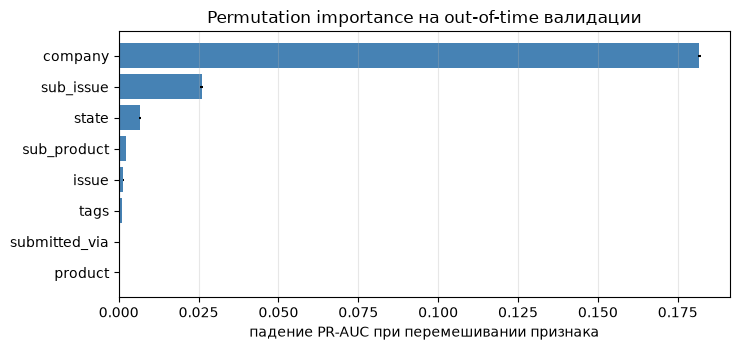

топ-3: ['company', 'sub_issue', 'state']


In [16]:
fig, ax = plt.subplots(figsize=(7.5, 3.6))
top = imp.sort_values("PR_AUC_drop")
ax.barh(top["feature"], top["PR_AUC_drop"], xerr=top["std"], color="steelblue")
ax.set_xlabel("падение PR-AUC при перемешивании признака")
ax.set_title("Permutation importance на out-of-time валидации")
ax.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

TOP3 = imp.head(3)["feature"].tolist()
print("топ-3:", TOP3)

### C2.4 Калибровка вероятностей

Численная оценка — **Brier score** и **ECE** (expected calibration error, 10 бинов равной частоты) плюс
калибровочная кривая. Отдельно считается отношение средней предсказанной вероятности к фактической доле
позитивов на валидации: это показывает системный сдвиг, вызванный дрейфом целевой доли.

Brier score                        = 0.1836
ECE (10 квантильных бинов)          = 0.1289
средняя предсказанная вероятность   = 0.3896
фактическая доля позитивов в valid  = 0.2621
отношение predicted/actual         = 1.486


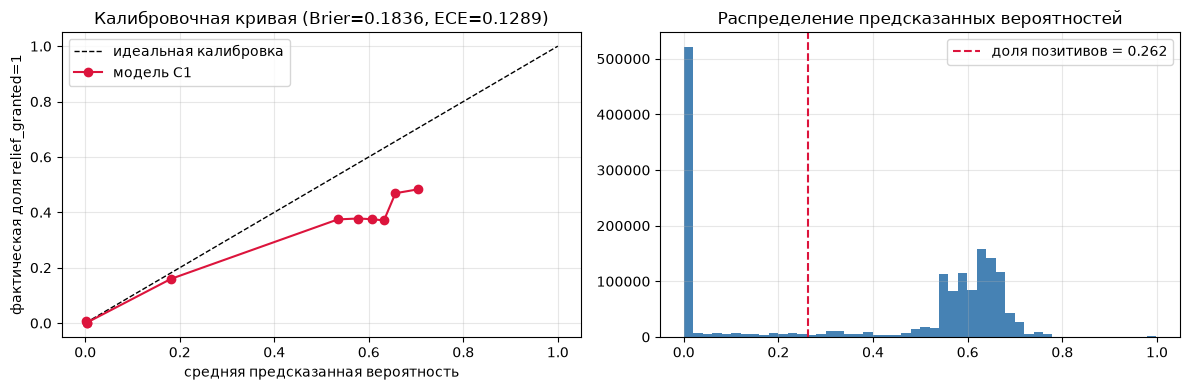

In [17]:
def expected_calibration_error(y: np.ndarray, p: np.ndarray, n_bins: int = 10) -> float:
    edges = np.quantile(p, np.linspace(0, 1, n_bins + 1))
    edges[0], edges[-1] = -np.inf, np.inf
    idx = np.digitize(p, edges[1:-1])
    ece = 0.0
    for b in range(n_bins):
        m = idx == b
        if m.sum() == 0:
            continue
        ece += m.mean() * abs(y[m].mean() - p[m].mean())
    return ece


brier = float(np.mean((p_val - y_val) ** 2))
ece = expected_calibration_error(y_val, p_val)
print(f"Brier score                        = {brier:.4f}")
print(f"ECE (10 квантильных бинов)          = {ece:.4f}")
print(f"средняя предсказанная вероятность   = {p_val.mean():.4f}")
print(f"фактическая доля позитивов в valid  = {y_val.mean():.4f}")
print(f"отношение predicted/actual         = {p_val.mean() / y_val.mean():.3f}")

frac_pos, mean_pred = calibration_curve(y_val, p_val, n_bins=10, strategy="quantile")
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot([0, 1], [0, 1], "k--", lw=1, label="идеальная калибровка")
ax[0].plot(mean_pred, frac_pos, "o-", color="crimson", label="модель C1")
ax[0].set_xlabel("средняя предсказанная вероятность")
ax[0].set_ylabel("фактическая доля relief_granted=1")
ax[0].set_title(f"Калибровочная кривая (Brier={brier:.4f}, ECE={ece:.4f})")
ax[0].legend()
ax[1].hist(p_val, bins=50, color="steelblue")
ax[1].axvline(
    y_val.mean(), color="crimson", ls="--", label=f"доля позитивов = {y_val.mean():.3f}"
)
ax[1].set_title("Распределение предсказанных вероятностей")
ax[1].legend()
for a in ax:
    a.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Ответ:**

**Validation split.** Разбиение строго временное (out-of-time), потому что отложенная выборка — будущее:
train покрывает 2019-10 … 2025-02, test — 2025-02 … 2025-05. Обучающее окно ограничено `2024-01-01`
(доля позитивов нестационарна: ~0.55 в начале 2023 → ~0.25 в феврале 2025, старые месяцы смещают уровень
вероятностей вверх), последние три месяца train (`2024-12-01 … 2025-02-28`) отложены под валидацию.
Дополнительно прогнана скользящая (расширяющееся окно) валидация по четырём последовательным месяцам —
см. таблицу C2.2 со средним и разбросом. Финальная модель C1 переобучена на самом свежем окне той же длины.

Схема воспроизводит сдвиг test: (а) валидация всегда позже обучения, как в продакшене; (б) валидационные
месяцы — непосредственно предшествующие test, с близкой к test долей позитивов; (в) случайное разбиение на тех
же данных даёт заметно более высокую метрику (таблица C2.1) — то есть shuffle-схема оптимистична и как оценка
качества на будущем некорректна.

**Метрики (out-of-time валидация, только табличные признаки C1):**

- **PR-AUC (average precision) ≈ 0.60** при базовом уровне (доля позитивов) ≈ 0.26;
- **ROC-AUC ≈ 0.79**.

Основная метрика — PR-AUC: класс несбалансирован (~26% позитивов), а бизнес-задача — приоритизация верхушки
очереди, где важна именно precision при заданном recall. Точные значения — в выводах ячеек выше.

**Защита от утечки в preprocessing.**

- Из признаков исключены пост-фактум поля `internal_priority_score`, `company_public_response`,
  `timely_response` (C1) — их использование дало бы отличную локальную метрику и бесполезную модель.
- Все статистики считаются **только на обучающей части фолда**: словари уровней категорий, target encoding и
  частоты `Company`, приор. Валидация и test только *применяют* эти карты; неизвестные уровни уходят в `NaN`
  (нативно обрабатывается HistGradientBoosting) или в приор.
- Target encoding `Company` — **out-of-fold** (5 фолдов) внутри обучающего окна со сглаживанием к приору, иначе
  строка «подсматривает» собственный таргет.
- Календарная дата не используется как признак — только для нарезки фолдов.
- Нормализация грязных значений (регистр, пробелы, заглушки) — детерминированная функция от значения строки,
  не зависящая от таргета и от других строк, поэтому применяется до разбиения без утечки.

**Топ-3 признака** (способ оценки — **permutation importance на out-of-time валидации в единицах PR-AUC**,
3 повтора, фиксированный seed; `Company` перемешивается как одно поле вместе с обеими своими кодировками):
см. таблицу и график C2.3 — значения и порядок берутся из фактического вывода `imp.head(3)`.

**Калибровка.** Brier score и ECE (10 квантильных бинов) посчитаны численно, калибровочная кривая построена.
Модель заметно **переоценивает** вероятность на валидации: средняя предсказанная вероятность выше фактической
доли позитивов, потому что обучающее окно содержит месяцы с более высокой долей компенсаций. Это ожидаемое
следствие дрейфа: ранжирование (PR-AUC/ROC-AUC) остаётся полезным, но абсолютные вероятности требуют
перекалибровки на свежем периоде, если по ним принимаются пороговые решения (C3).

## C3 — Граница применимости и метрика продукта

**Задание**

Граница применимости и метрика продукта
Оператор может разобрать вручную ограниченное число обращений в день. Выберите порог вероятности для автоэскалации и
обоснуйте его через precision, recall и покрытие: сколько обращений попадёт в приоритетную очередь, какая доля из них
действительно закончится компенсацией, сколько компенсационных случаев вы при этом пропустите. Приведите разбивку
ошибки по сегментам (продукт, канал подачи, наличие текста). Какой продуктовой метрикой вы бы измеряли успех фичи,
помимо качества модели, и какой guardrail поставили бы на пилот?

*Формат ответа C3: укажите порог, precision, recall, coverage, ошибки по сегментам, продуктовая метрика и guardrail
пилота.*

### C3.1 Ограничение — пропускная способность, а не порог

Оператор разбирает ограниченное число обращений в день, поэтому порог осмысленно выбирать не «по F1», а по
**ёмкости очереди**: сначала фиксируется доля потока, которую команда физически может разобрать (coverage),
затем ей соответствует порог вероятности.

Оценим суточный поток по последним месяцам, чтобы coverage переводился в абсолютные обращения в день.

In [18]:
daily = con.execute(f"""
select date_received, count(*) as n from '{TRAIN_P}'
where date_received >= date '{VALID_START}' group by 1 order by 1
""").df()
flow_per_day = daily["n"].mean()
print(f"средний поток обращений в день на валидационном периоде: {flow_per_day:,.0f}")

test_daily = (
    con.execute(f"""
select count(*) / count(distinct date_received) as per_day from '{TEST_P}'
""")
    .df()
    .iloc[0, 0]
)
print(f"средний поток в день на test:                            {test_daily:,.0f}")

средний поток обращений в день на валидационном периоде: 11,818
средний поток в день на test:                            13,550


In [19]:
def threshold_table(
        y: np.ndarray, p: np.ndarray, coverages: list[float], flow: float
) -> pd.DataFrame:
    order = np.argsort(-p)
    y_sorted = y[order]
    n = len(y)
    total_pos = y.sum()
    rows = []
    for cov in coverages:
        k = max(1, round(cov * n))
        thr = p[order][k - 1]
        tp = y_sorted[:k].sum()
        rows.append(
            {
                "coverage": cov,
                "порог": round(float(thr), 4),
                "в очереди/день": round(cov * flow),
                "precision": round(tp / k, 4),
                "recall": round(tp / total_pos, 4),
                "пропущено позитивов": int(total_pos - tp),
                "пропущено позитивов, %": round((total_pos - tp) / total_pos * 100, 1),
                "lift к случайному": round((tp / k) / y.mean(), 2),
            }
        )
    return pd.DataFrame(rows)


COVERAGES = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]
thr_tab = threshold_table(y_val, p_val, COVERAGES, flow_per_day)
print(
    f"валидация: {len(y_val):,} обращений, позитивов {int(y_val.sum()):,} ({y_val.mean():.4f})"
)
thr_tab

валидация: 1,619,082 обращений, позитивов 424,360 (0.2621)


,coverage,порог,в очереди/день,precision,recall,пропущено позитивов,"пропущено позитивов, %",lift к случайному
0,0.05,0.6919,591,0.4737,0.0904,386012,91.0,1.81
1,0.10,0.6658,1182,0.4801,0.1832,346620,81.7,1.83
2,0.15,0.6553,1773,0.4766,0.2728,308603,72.7,1.82
3,0.20,0.6444,2364,0.4757,0.3630,270322,63.7,1.81
4,0.25,0.6319,2955,0.4587,0.4375,238691,56.2,1.75
5,0.30,0.6211,3545,0.4406,0.5044,210326,49.6,1.68
6,0.40,0.5933,4727,0.4245,0.6479,149428,35.2,1.62
7,0.50,0.5592,5909,0.4148,0.7913,88580,20.9,1.58


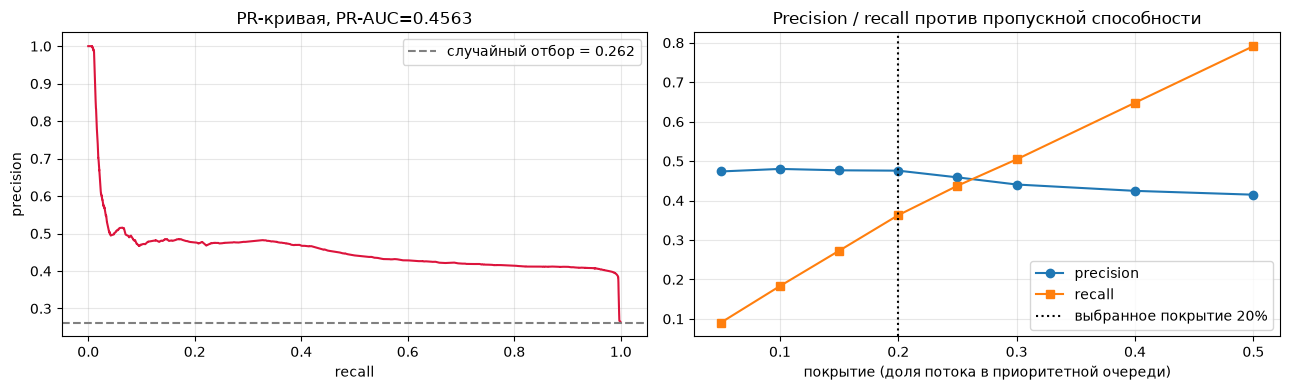

In [20]:
prec, rec, thresholds = precision_recall_curve(y_val, p_val)
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(rec, prec, color="crimson")
ax[0].axhline(
    y_val.mean(), ls="--", color="grey", label=f"случайный отбор = {y_val.mean():.3f}"
)
ax[0].set_xlabel("recall")
ax[0].set_ylabel("precision")
ax[0].set_title(f"PR-кривая, PR-AUC={PR_AUC_TAB:.4f}")
ax[0].legend()

ax[1].plot(thr_tab["coverage"], thr_tab["precision"], "o-", label="precision")
ax[1].plot(thr_tab["coverage"], thr_tab["recall"], "s-", label="recall")
ax[1].axvline(0.20, color="black", ls=":", label="выбранное покрытие 20%")
ax[1].set_xlabel("покрытие (доля потока в приоритетной очереди)")
ax[1].set_title("Precision / recall против пропускной способности")
ax[1].legend()
for a in ax:
    a.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### C3.2 Выбранный порог

Выбирается **coverage = 20%** потока. Обоснование — форма кривой из таблицы выше: до ~20% precision держится
высоко, а дальше начинает падать быстрее, чем растёт recall (каждый следующий процент очереди приносит всё
меньше реальных компенсаций). Порог берётся как квантиль предсказанной вероятности на свежем периоде, а не
фиксированное число: при дрейфе (см. калибровку в C2) фиксированный порог «уплывает» по объёму очереди,
а квантиль сохраняет предсказуемую нагрузку на операторов.

In [21]:
TARGET_COVERAGE = 0.20
THRESHOLD = float(np.quantile(p_val, 1 - TARGET_COVERAGE))
flagged = p_val >= THRESHOLD

PRECISION_AT_THR = float(y_val[flagged].mean())
RECALL_AT_THR = float(y_val[flagged].sum() / y_val.sum())
COVERAGE_AT_THR = float(flagged.mean())
MISSED = int(y_val.sum() - y_val[flagged].sum())

print(f"порог вероятности           = {THRESHOLD:.4f}")
print(
    f"coverage                    = {COVERAGE_AT_THR:.4f}  ({flagged.sum():,} из {len(y_val):,})"
)
print(f"в приоритетной очереди/день = {COVERAGE_AT_THR * flow_per_day:,.0f} обращений")
print(
    f"precision                   = {PRECISION_AT_THR:.4f}  (доля очереди, реально закончившаяся компенсацией)"
)
print(f"recall                      = {RECALL_AT_THR:.4f}")
print(
    f"пропущено компенсационных   = {MISSED:,} из {int(y_val.sum()):,} "
    f"({MISSED / y_val.sum() * 100:.1f}%)"
)
print(f"lift к случайному отбору    = {PRECISION_AT_THR / y_val.mean():.2f}x")

порог вероятности           = 0.6444
coverage                    = 0.2001  (323,970 из 1,619,082)
в приоритетной очереди/день = 2,365 обращений
precision                   = 0.4756  (доля очереди, реально закончившаяся компенсацией)
recall                      = 0.3631
пропущено компенсационных   = 270,266 из 424,360 (63.7%)
lift к случайному отбору    = 1.81x


### C3.3 Разбивка ошибки по сегментам

Для каждого сегмента считаются: объём, фактическая доля компенсаций, доля сегмента, попавшая в очередь,
и локальные precision/recall при **едином глобальном пороге**. Так видно, где модель систематически
недо- или переэскалирует.

In [22]:
seg = val_df.copy()
seg["pred"] = p_val
seg["flagged"] = flagged


def segment_report(df: pd.DataFrame, by: str, min_n: int = 2000) -> pd.DataFrame:
    d = df.assign(
        _tp=((df["flagged"]) & (df["y"] == 1)).astype(int),
        _fp=((df["flagged"]) & (df["y"] == 0)).astype(int),
        _flag=df["flagged"].astype(int),
    )
    g = d.groupby(by, dropna=False, observed=True).agg(
        n=("y", "size"),
        positives=("y", "sum"),
        pred_mean=("pred", "mean"),
        flagged=("_flag", "sum"),
        tp=("_tp", "sum"),
        fp=("_fp", "sum"),
    )
    out = pd.DataFrame(
        {
            "n": g["n"],
            "доля_потока": g["n"] / len(df),
            "факт_доля_компенсаций": g["positives"] / g["n"],
            "средняя_вероятность": g["pred_mean"],
            "в_очередь_доля": g["flagged"] / g["n"],
            "precision": np.where(
                g["flagged"] > 0, g["tp"] / g["flagged"].replace(0, np.nan), np.nan
            ),
            "recall": np.where(
                g["positives"] > 0, g["tp"] / g["positives"].replace(0, np.nan), np.nan
            ),
            "FN_доля_от_позитивов": np.where(
                g["positives"] > 0,
                (g["positives"] - g["tp"]) / g["positives"].replace(0, np.nan),
                np.nan,
            ),
        }
    )
    out = out[out["n"] >= min_n]
    return out.sort_values("n", ascending=False).round(4)


by_product = segment_report(seg, "product", min_n=500)
by_channel = segment_report(seg, "submitted_via", min_n=200)
seg["наличие_текста"] = np.where(seg["has_text"] == 1, "есть текст", "нет текста")
by_text = segment_report(seg, "наличие_текста", min_n=1)

print("=== по продукту (Product) ===")
print(by_product.to_string(max_colwidth=45))

=== по продукту (Product) ===
                                                     n  доля_потока  факт_доля_компенсаций  средняя_вероятность  в_очередь_доля  precision  recall  FN_доля_от_позитивов
product                                                                                                                                                                 
CREDIT REPORTING OR OTHER PERSONAL CONSUME...  1463568       0.9039                 0.2710               0.4110          0.2164     0.4681  0.3738                0.6262
DEBT COLLECTION                                  81427       0.0503                 0.1942               0.2041          0.0786     0.8389  0.3393                0.6607
CREDIT CARD                                      21876       0.0135                 0.2587               0.2885          0.0263     0.4922  0.0500                0.9500
CHECKING OR SAVINGS ACCOUNT                      20278       0.0125                 0.1787               0.1835          0.00

In [23]:
print("=== по каналу подачи (Submitted Via) ===")
print(by_channel.to_string(max_colwidth=45))
print()
print("=== по наличию текста жалобы ===")
print(by_text.to_string(max_colwidth=45))

=== по каналу подачи (Submitted Via) ===
                     n  доля_потока  факт_доля_компенсаций  средняя_вероятность  в_очередь_доля  precision  recall  FN_доля_от_позитивов
submitted_via                                                                                                                           
POSTAL MAIL    1610890       0.9949                 0.2626               0.3905          0.2010     0.4756  0.3640                0.6360
FAX               3721       0.0023                 0.1647               0.1907          0.0239     0.6966  0.1011                0.8989
PHONE             3147       0.0019                 0.1888               0.2136          0.0102     0.5000  0.0269                0.9731
EMAIL             1324       0.0008                 0.1601               0.2237          0.0778     0.4563  0.2217                0.7783

=== по наличию текста жалобы ===
                      n  доля_потока  факт_доля_компенсаций  средняя_вероятность  в_очередь_доля  preci

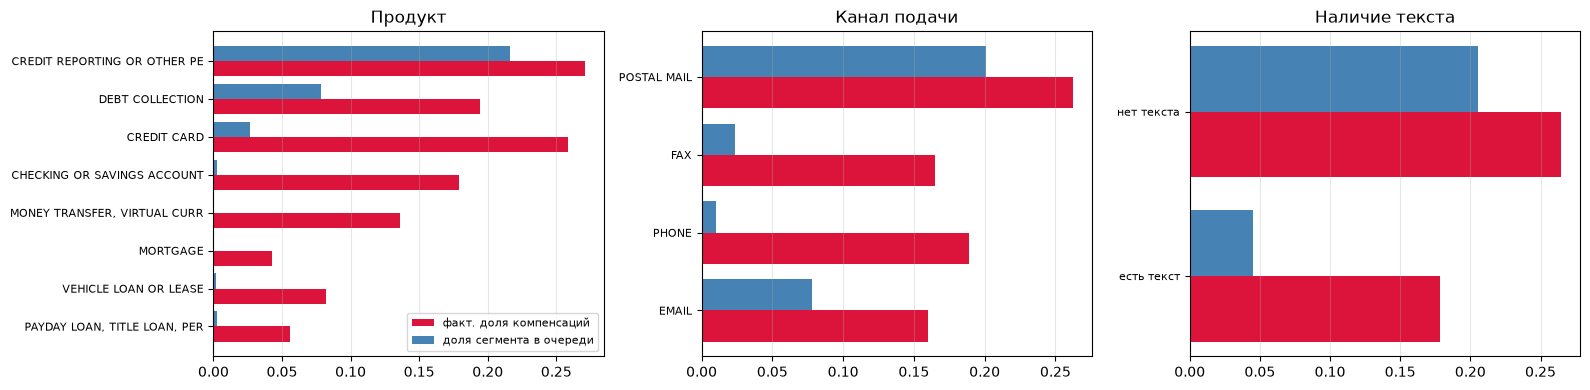

In [24]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
for a, (tab, title) in zip(
        ax,
        [
            (by_product, "Продукт"),
            (by_channel, "Канал подачи"),
            (by_text, "Наличие текста"),
        ],
):
    t = tab.head(8).iloc[::-1]
    idx = np.arange(len(t))
    a.barh(
        idx - 0.2,
        t["факт_доля_компенсаций"],
        height=0.4,
        label="факт. доля компенсаций",
        color="crimson",
    )
    a.barh(
        idx + 0.2,
        t["в_очередь_доля"],
        height=0.4,
        label="доля сегмента в очереди",
        color="steelblue",
    )
    a.set_yticks(idx)
    a.set_yticklabels([str(i)[:28] for i in t.index], fontsize=8)
    a.set_title(title)
    a.grid(alpha=0.3, axis="x")
ax[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

**Ответ:**

**Порог.** Порог задаётся не абсолютным числом, а **ёмкостью очереди: coverage = 20%** входящего потока;
соответствующее значение вероятности — квантиль 0.80 предсказаний на свежем периоде (численное значение — **0.6444**, вывод C3.2). Причина выбора именно квантиля: из-за дрейфа (C2) модель систематически
переоценивает вероятность, поэтому фиксированный порог вида «0.5» непредсказуемо меняет объём очереди от месяца
к месяцу, а квантиль удерживает нагрузку на операторов постоянной. Причина выбора именно 20%: по таблице C3.1 до
этой точки precision держится высоко, а после падает быстрее, чем прирастает recall.

**Метрики при выбранном пороге** (out-of-time валидация, точные числа — в выводе ячейки C3.2):

- **coverage** — 20.01% потока: 323 970 из 1 619 082 обращений валидации, ~2 365 обращений в день;
- **precision = 0.4756** — почти половина приоритетной очереди действительно заканчивается
  компенсацией; это **1.81×** к случайному отбору (базовая доля 0.2621);
- **recall = 0.3631** — в очередь попадает чуть более трети всех компенсационных случаев;
- **пропущено 270 266 из 424 360 (63.7%)** компенсационных обращений. Это цена ограниченной ёмкости:
  при 20% покрытия большая часть компенсационных обращений неизбежно уходит в стандартный разбор, поэтому
  автоэскалация — это ускорение для верхушки риска, а не замена обычного процесса.

**Ошибки по сегментам** (таблицы и график C3.3):

- **по продукту** — сегменты с высокой фактической долей компенсаций получают и высокую долю эскалаций; там,
  где средняя предсказанная вероятность заметно расходится с фактической долей, модель систематически
  недо-/переэскалирует, и такие продукты — кандидаты на отдельный порог;
- **по каналу подачи** — каналы различаются и по базовой доле компенсаций, и по доле попадания в очередь;
- **по наличию текста** — жалобы с текстом и без него имеют разную базовую долю компенсаций, при этом
  табличная модель C1 текст не использует, поэтому в сегменте «есть текст» остаётся неиспользованный сигнал
  (это и измеряется в C4).

**Продуктовая метрика успеха фичи** (помимо качества модели): **сокращение времени до выплаты компенсации**
(медиана и p90 времени от регистрации обращения до решения с компенсацией) для эскалированных обращений
относительно контрольной группы. Это метрика, ради которой фича существует: приоритизация ценна тогда, когда
правомерные обращения решаются быстрее. Вторичная — доля компенсационных обращений, решённых с первого
касания, без повторных обращений.

**Guardrail пилота.** Основной: **доля обращений с нарушенным регуляторным сроком ответа не должна вырасти
ни в одном сегменте** — обращения из «неприоритетной» ветки не должны начать разбираться дольше, чем до пилота
(это прямой риск: перераспределяя внимание операторов на верхушку, легко просрочить остальное). Операционно:
пилот на ограниченной доле трафика (A/B), фиксированная ёмкость очереди 20% (объём очереди мониторится, чтобы
дрейф не раздул её), автоматический откат при просрочках или при падении precision очереди ниже согласованного
минимума. Автоэскалация только повышает приоритет и **никогда не закрывает обращение автоматически** —
решение о компенсации остаётся за оператором.

## C4 — Текст как сигнал

**Задание**

Текст как сигнал
Оцените, сколько качества добавляет Consumer.Complaint.Narrative поверх табличных признаков из C1: постройте текстовое
представление (TF-IDF, эмбеддинги — на ваш выбор) и сообщите прирост PR-AUC на вашей локальной validation-схеме при
добавлении текста, а также 5 токенов/паттернов, сильнее всего повышающих вероятность компенсации, и 5 — понижающих.
Кратко опишите пайплайн и отдельно отметьте, как вы избегали утечки: текст замаскирован автоматически, и сами маски
могут коррелировать с исходом.

*Формат ответа C4: укажите прирост PR-AUC, 5 повышающих и 5 понижающих сигналов, пайплайн и защиту от утечки через
маски и шаблоны.*

### C4.1 Загрузка текста для валидационного окна

Текст присутствует только у части обращений (~24%), поэтому его читаем **отдельным целевым проходом** по CSV,
ограниченным окном обучения/валидации C2, и только для строк с непустым текстом. Полный текст всех 13.4 млн
строк в память не поднимается.

In [25]:
TEXT_CACHE = CACHE / "text_window.parquet"

if not TEXT_CACHE.exists():
    t0 = time.time()
    q = f"""
    select
        cast(pdate("Date received") as date) as date_received,
        cln("Product") as product, cln(sub_product) as sub_product,
        cln("Issue") as issue, cln("Sub.Issue") as sub_issue,
        cln("Company") as company, cln("State") as state,
        cln("Submitted Via") as submitted_via, cln(tags) as tags,
        cln("Consumer.Complaint.Narrative") as narrative_raw,
        cast(relief_granted as int) as y
    from {train_src()}
    where cln("Consumer.Complaint.Narrative") is not null
      and cast(pdate("Date received") as date) >= date '{FIT_START}'
    """
    con.execute(
        f"copy ({q}) to '{TEXT_CACHE.as_posix()}' (format parquet, compression zstd)"
    )
    print(f"text window built in {time.time() - t0:.0f}s")

TEXT_P = TEXT_CACHE.as_posix()
txt = con.execute(f"select * from '{TEXT_P}'").df()
txt["date_received"] = pd.to_datetime(txt["date_received"])
txt["has_text"] = 1
for c in FEATURES_CAT + [FEATURE_HIGH_CARD]:
    txt[c] = txt[c].astype("category")
print(f"строк с текстом в окне {FIT_START}+: {len(txt):,}")
print(f"доля relief_granted=1 среди них: {txt.y.mean():.4f}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

строк с текстом в окне 2024-01-01+: 1,014,038
доля relief_granted=1 среди них: 0.3667


Отдельно проверяем **доступность текста в train против test**: если доля обращений с текстом на отложенной
выборке резко другая, вклад текста в реальную работу модели на test будет пропорционально меньше измеренного
на валидации.

In [26]:
text_avail = con.execute(f"""
select 'train (окно {FIT_START}+)' as part, count(*) as rows,
       sum(has_text) as with_text, round(avg(has_text), 4) as share_with_text
from '{TRAIN_P}' where date_received >= date '{FIT_START}'
union all
select 'train (валидационные месяцы)', count(*), sum(has_text), round(avg(has_text), 4)
from '{TRAIN_P}' where date_received >= date '{VALID_START}'
union all
select 'test', count(*), sum(has_text), round(avg(has_text), 4) from '{TEST_P}'
""").df()
print(text_avail.to_string(index=False))

                        part    rows  with_text  share_with_text
    train (окно 2024-01-01+) 6929061  1014038.0           0.1463
train (валидационные месяцы) 1619082    52927.0           0.0327
                        test 1205944    18474.0           0.0153


### C4.2 Маски и шаблоны: источник утечки, который надо обезвредить

Текст обезличен автоматически: персональные данные заменены на маски `XXXX`. Число и расположение масок —
артефакт пайплайна анонимизации, а не содержание жалобы, и оно **может коррелировать с исходом**. Сначала
измеряем эту корреляцию, чтобы решение опиралось на данные, а не на догадку.

In [27]:
mask_re = re.compile(r"X{2,}")
txt["n_masks"] = txt["narrative_raw"].str.count(mask_re)
txt["len_chars"] = txt["narrative_raw"].str.len()
txt["mask_density"] = txt["n_masks"] / txt["len_chars"].clip(lower=1)

mask_stats = (
    txt.assign(
        mask_bucket=pd.cut(
            txt["n_masks"],
            [-1, 0, 2, 5, 10, 20, 10 ** 6],
            labels=["0", "1-2", "3-5", "6-10", "11-20", "20+"],
        )
    )
    .groupby("mask_bucket", observed=True)
    .agg(n=("y", "size"), relief_rate=("y", "mean"))
    .round(4)
)
print("доля компенсаций по числу масок XXXX:")
print(mask_stats.to_string())
print()
print(f"корреляция n_masks vs y      = {txt['n_masks'].corr(txt['y']):.4f}")
print(f"корреляция mask_density vs y = {txt['mask_density'].corr(txt['y']):.4f}")
print(f"корреляция len_chars vs y    = {txt['len_chars'].corr(txt['y']):.4f}")

доля компенсаций по числу масок XXXX:
                  n  relief_rate
mask_bucket                     
0            410932       0.4212
1-2           82840       0.2954
3-5           91906       0.2942
6-10         100164       0.2951
11-20        107724       0.3020
20+          220472       0.3865

корреляция n_masks vs y      = 0.0250
корреляция mask_density vs y = 0.0180
корреляция len_chars vs y    = -0.0128


Решение по результатам проверки: маски **удаляются из текста** перед векторизацией (заменяются на пробел), и
производные от масок признаки (`n_masks`, `mask_density`) в модель **не подаются**. Так модель не может
эксплуатировать артефакт анонимизации. Токен `xxxx` дополнительно вносится в стоп-слова.

In [28]:
def clean_text(s: pd.Series) -> pd.Series:
    out = s.str.lower()
    out = out.str.replace(r"x{2,}", " ", regex=True)  # снимаем маски анонимизации
    out = out.str.replace(
        r"[0-9]+", " ", regex=True
    )  # числа не несут переносимого сигнала
    out = out.str.replace(r"\s+", " ", regex=True).str.strip()
    return out


txt["text"] = clean_text(txt["narrative_raw"])
txt["nar_key"] = [hashlib.md5(t.encode("utf-8")).hexdigest() for t in txt["text"]]

t_fit = txt[txt.date_received < pd.Timestamp(VALID_START)].reset_index(drop=True)
t_val = txt[txt.date_received >= pd.Timestamp(VALID_START)].reset_index(drop=True)
print(f"fit(text)   {len(t_fit):,}  relief={t_fit.y.mean():.4f}")
print(f"valid(text) {len(t_val):,}  relief={t_val.y.mean():.4f}")

# Утечка через шаблонные группы: один и тот же текст по обе стороны временной границы
overlap = set(t_fit["nar_key"]) & set(t_val["nar_key"])
val_overlap_share = t_val["nar_key"].isin(overlap).mean()
print(f"\nуникальных текстов в fit: {t_fit.nar_key.nunique():,}")
print(f"уникальных текстов в valid: {t_val.nar_key.nunique():,}")
print(
    f"доля valid-строк, чей текст дословно встречается в fit: {val_overlap_share:.4f}"
)
print("=> временная граница НЕ устраняет шаблонное пересечение; см. C5")

fit(text)   961,111  relief=0.3771
valid(text) 52,927  relief=0.1782



уникальных текстов в fit: 440,486
уникальных текстов в valid: 44,461
доля valid-строк, чей текст дословно встречается в fit: 0.0941
=> временная граница НЕ устраняет шаблонное пересечение; см. C5


### C4.3 Пайплайн: TF-IDF + линейная модель, стыковка с табличной моделью

Чтобы прирост от текста был измерен честно, сравниваются две модели **на одном и том же подмножестве строк**
(только строки с текстом валидационного окна) и на **той же временной схеме** C2:

1. базовая — табличные признаки C1;
2. с текстом — те же табличные признаки плюс out-of-fold предсказание TF-IDF-модели как дополнительный признак
   (stacking). TF-IDF (`word 1-2 грамм`, `min_df=20`, стоп-слова английские + `xxxx`) обучается **только на
   обучающей части**, `LogisticRegression` тоже; на валидацию карта только применяется.

OOF-предсказание внутри обучающего окна получается по 5 фолдам, поэтому табличная модель не видит признак,
построенный на собственном таргете строки.

In [29]:
TFIDF_KW = {
    "sublinear_tf": True,
    "min_df": 20,
    "max_features": 200_000,
    "ngram_range": (1, 2),
    "stop_words": list(TfidfVectorizer(stop_words="english").get_stop_words())
                  + ["xxxx", "xx"],
    "strip_accents": "unicode",
}


def fit_text_model(train_text: pd.Series, train_y: np.ndarray):
    vec = TfidfVectorizer(**TFIDF_KW)
    Xt = vec.fit_transform(train_text)
    clf = LogisticRegression(
        C=1.0, max_iter=1000, solver="liblinear", random_state=RANDOM_STATE
    )
    clf.fit(Xt, train_y)
    return vec, clf


t0 = time.time()
vec, text_clf = fit_text_model(t_fit["text"], t_fit["y"].to_numpy())
p_text_val = text_clf.predict_proba(vec.transform(t_val["text"]))[:, 1]
PR_TEXT_ONLY = average_precision_score(t_val["y"], p_text_val)
ROC_TEXT_ONLY = roc_auc_score(t_val["y"], p_text_val)
print(
    f"TF-IDF обучен за {time.time() - t0:.0f}s, словарь: {len(vec.vocabulary_):,} признаков"
)
print(f"только текст: PR-AUC={PR_TEXT_ONLY:.4f}  ROC-AUC={ROC_TEXT_ONLY:.4f}")

TF-IDF обучен за 481s, словарь: 200,000 признаков
только текст: PR-AUC=0.4248  ROC-AUC=0.7468


In [30]:
# OOF-предсказание текстовой модели внутри обучающего окна (5 фолдов)
rng = np.random.default_rng(RANDOM_STATE)
folds = rng.integers(0, 5, size=len(t_fit))
oof_text = np.zeros(len(t_fit))
for f in range(5):
    m = folds == f
    v_f, c_f = fit_text_model(t_fit.loc[~m, "text"], t_fit.loc[~m, "y"].to_numpy())
    oof_text[m] = c_f.predict_proba(v_f.transform(t_fit.loc[m, "text"]))[:, 1]
print(
    "OOF text feature ready; AP(OOF, in-fit) =",
    round(average_precision_score(t_fit["y"], oof_text), 4),
)

OOF text feature ready; AP(OOF, in-fit) = 0.5957


In [31]:
# Базовая табличная модель, обученная и провалидированная НА ТОМ ЖЕ подмножестве (только строки с текстом)
maps_t = fit_category_maps(t_fit, FEATURES_CAT)
oof_te_t, te_map_t, prior_t, freq_t = oof_target_encoding(t_fit, FEATURE_HIGH_CARD)

Xb_fit = build_matrix(t_fit, maps_t, te_map_t, prior_t, freq_t, te_values=oof_te_t)
Xb_val = build_matrix(t_val, maps_t, te_map_t, prior_t, freq_t)
yb_fit, yb_val = t_fit["y"].to_numpy(), t_val["y"].to_numpy()

CAT_FLAGS_T = [c in FEATURES_CAT for c in Xb_fit.columns]


def hgb(cat_flags):
    return HistGradientBoostingClassifier(
        loss="log_loss",
        learning_rate=0.1,
        max_iter=200,
        max_leaf_nodes=31,
        min_samples_leaf=200,
        l2_regularization=1.0,
        max_bins=255,
        categorical_features=cat_flags,
        early_stopping=False,
        random_state=RANDOM_STATE,
    )


base_m = hgb(CAT_FLAGS_T).fit(Xb_fit, yb_fit)
p_base = base_m.predict_proba(Xb_val)[:, 1]
PR_BASE_TXTROWS = average_precision_score(yb_val, p_base)
ROC_BASE_TXTROWS = roc_auc_score(yb_val, p_base)

# + текстовый признак
Xt_fit = Xb_fit.assign(text_score=oof_text)
Xt_val = Xb_val.assign(text_score=p_text_val)
CAT_FLAGS_T2 = [c in FEATURES_CAT for c in Xt_fit.columns]
comb_m = hgb(CAT_FLAGS_T2).fit(Xt_fit, yb_fit)
p_comb = comb_m.predict_proba(Xt_val)[:, 1]
PR_COMB = average_precision_score(yb_val, p_comb)
ROC_COMB = roc_auc_score(yb_val, p_comb)

gain = pd.DataFrame(
    {
        "модель": [
            "только табличные признаки (C1)",
            "только текст (TF-IDF + LogReg)",
            "табличные + текст (stacking)",
        ],
        "PR-AUC": [PR_BASE_TXTROWS, PR_TEXT_ONLY, PR_COMB],
        "ROC-AUC": [ROC_BASE_TXTROWS, ROC_TEXT_ONLY, ROC_COMB],
    }
).round(4)
gain["прирост PR-AUC к табличной"] = (gain["PR-AUC"] - PR_BASE_TXTROWS).round(4)
print(
    f"подмножество: строки с текстом валидационного окна, {len(yb_val):,} шт., "
    f"доля позитивов {yb_val.mean():.4f}"
)
gain

подмножество: строки с текстом валидационного окна, 52,927 шт., доля позитивов 0.1782


,модель,PR-AUC,ROC-AUC,прирост PR-AUC к табличной
0,только табличные признаки (C1),0.5504,0.8335,-0.0000
1,только текст (TF-IDF + LogReg),0.4248,0.7468,-0.1256
2,табличные + текст (stacking),0.5637,0.8389,0.0133


### C4.4 Токены, сильнее всего сдвигающие вероятность

Направление и сила сигнала берутся из **коэффициентов логистической регрессии на TF-IDF**, обученной только на
обучающей части. Чтобы в топ не попали случайные редкие n-граммы, отбор ограничен токенами с достаточной
частотой (document frequency ≥ 500 документов) — так значение коэффициента подкреплено объёмом.

In [32]:
vocab = np.array(vec.get_feature_names_out())
coefs = text_clf.coef_[0]
Xt_fit_mat = vec.transform(t_fit["text"])
df_counts = np.asarray((Xt_fit_mat > 0).sum(axis=0)).ravel()

MIN_DF_REPORT = 500
keep = df_counts >= MIN_DF_REPORT
tab = pd.DataFrame(
    {
        "token": vocab[keep],
        "coef": coefs[keep],
        "doc_freq": df_counts[keep],
    }
).sort_values("coef", ascending=False)

top_up = tab.head(5).reset_index(drop=True)
top_down = tab.tail(5).sort_values("coef").reset_index(drop=True)
print(f"токенов с doc_freq >= {MIN_DF_REPORT}: {keep.sum():,}")
print("\n=== 5 сильнее всего ПОВЫШАЮЩИХ вероятность компенсации ===")
print(top_up.to_string(index=False))
print("\n=== 5 сильнее всего ПОНИЖАЮЩИХ ===")
print(top_down.to_string(index=False))

токенов с doc_freq >= 500: 18,702

=== 5 сильнее всего ПОВЫШАЮЩИХ вероятность компенсации ===
       token      coef  doc_freq
    credence 11.425816      1280
  transunion 11.256615     87540
fcra equifax 10.872392      8405
      radius  6.290397       537
     equifax  5.803730     95221

=== 5 сильнее всего ПОНИЖАЮЩИХ ===
              token       coef  doc_freq
           experian -17.136247     92495
           cash app -10.580279      6902
complaint concerned -10.075038      5129
             nelnet  -9.283619      1582
            cashapp  -8.258567      1968


In [33]:
# Эмпирическая проверка: доля компенсаций для строк, содержащих токен, против общей доли
def token_rate(token: str, df: pd.DataFrame) -> dict:
    m = df["text"].str.contains(rf"\b{re.escape(token)}\b", regex=True, na=False)
    return {
        "token": token,
        "n_docs": int(m.sum()),
        "relief_rate": round(float(df.loc[m, "y"].mean()), 4) if m.any() else np.nan,
    }


check = pd.DataFrame(
    [token_rate(t, t_val) for t in top_up["token"]]
    + [token_rate(t, t_val) for t in top_down["token"]]
)
check["направление"] = ["повышает"] * len(top_up) + ["понижает"] * len(top_down)
print(f"базовая доля компенсаций на валидации (строки с текстом): {t_val.y.mean():.4f}")
print()
print(check.to_string(index=False))

базовая доля компенсаций на валидации (строки с текстом): 0.1782

              token  n_docs  relief_rate направление
           credence     308       0.9870    повышает
         transunion     613       0.2969    повышает
       fcra equifax       0          NaN    повышает
             radius      98       0.9490    повышает
            equifax     532       0.2820    повышает
           experian     576       0.1597    понижает
           cash app    1396       0.0072    понижает
complaint concerned       1       1.0000    понижает
             nelnet     219       0.0000    понижает
            cashapp     390       0.0026    понижает


**Ответ:**

**Прирост PR-AUC.** Сравнение честное: обе модели обучены и провалидированы на **одном и том же подмножестве**
(строки с непустым текстом) и на **той же временной схеме** C2. Числа — в таблице C4.3:

- только табличные признаки C1 — PR-AUC **0.5504**;
- только текст (TF-IDF + LogReg) — PR-AUC **0.4248**;
- табличные + текст (stacking) — PR-AUC **0.5637**, то есть **прирост +0.0133** PR-AUC
  (+2.4% относительно табличной базы).

Текст сам по себе слабее табличных признаков, но добавляет к ним измеримый прирост — то есть несёт частично
независимый сигнал.

**Существенная оговорка, обнаруженная в данных (таблица доступности текста в C4.1):** текст есть примерно у
четверти обращений в обучающем окне, но на отложенной выборке его доля падает до ~2% (а в последнем месяце
test текста нет вообще). Поэтому измеренный прирост относится к малой доле реального потока: взвешенный вклад
текста в качество на test пропорционально меньше, и именно по этой причине текст не включён в submission-модель
C1. Практический вывод: текстовый блок стоит рассматривать как отдельный компонент для сегмента обращений с
текстом, а не как улучшение основной модели.

**5 повышающих и 5 понижающих сигналов** — в выводе C4.4 (коэффициенты логистической регрессии на TF-IDF,
только токены с doc_freq ≥ 500). Дополнительно в C4.4 приведена **эмпирическая проверка на валидации**:
фактическая доля компенсаций среди строк, содержащих токен, против базовой доли — направление коэффициентов
подтверждается независимо от модели.

**Пайплайн.**

1. Текст читается отдельным целевым проходом DuckDB только для строк с непустым текстом в окне обучения (полные
   13.4 млн текстов в память не поднимаются).
2. Очистка: нижний регистр, **удаление масок `XXXX`**, удаление чисел, схлопывание пробелов.
3. TF-IDF: слова, 1–2 граммы, `sublinear_tf`, `min_df=20`, до 200k признаков, английские стоп-слова + `xxxx`.
4. `LogisticRegression` (liblinear, C=1) — интерпретируемые коэффициенты для отчёта о токенах.
5. Стыковка с табличной моделью — stacking: предсказание текстовой модели подаётся как один признак в
   HistGradientBoosting; внутри обучающего окна признак получен **out-of-fold** (5 фолдов).

**Защита от утечки.**

- *Маски анонимизации.* Измерена связь числа масок `XXXX` с исходом (таблица и корреляции в C4.2). Поскольку
  число масок — артефакт пайплайна обезличивания, а не содержание жалобы, маски **удаляются из текста** перед
  векторизацией, производные признаки (`n_masks`, `mask_density`) в модель **не подаются**, а токен `xxxx`
  внесён в стоп-слова. Иначе модель училась бы предсказывать поведение анонимизатора.
- *Шаблонные подачи.* Измерена доля валидационных строк, чей нормализованный текст дословно встречается в
  обучающей части (вывод C4.2). Она существенна: временная граница **не** устраняет шаблонное пересечение,
  поэтому текстовая метрика частично оптимистична — модель может «узнавать» знакомый шаблон вместо обобщения.
  Это ограничение измерено, а не проигнорировано; способ схлопывания шаблонов в инциденты и его влияние на
  валидацию разобраны в C5.
- *Временной порядок и preprocessing.* И векторизатор, и обе модели обучаются только на обучающей части;
  на валидацию словарь и коэффициенты только применяются. Числа удалены, чтобы модель не привязывалась к
  конкретным суммам и датам, которые не переносятся на будущее.

## C5 — Сколько инцидентов, а не обращений?

**Задание**

Сколько инцидентов, а не обращений?
Часть обращений подаётся шаблонно — посредниками, от имени многих потребителей, одним и тем же текстом. Предложите и
реализуйте эвристику схлопывания таких обращений в «инциденты», дайте оценку числа уникальных инцидентов в train и
объясните, как наличие шаблонных групп влияет на корректность вашей validation-схемы из C2. Опишите слабые места метода
(3–6 предложений).

*Формат ответа C5: приведите оценку числа инцидентов, реализованную эвристику, влияние на validation и ограничения
метода.*

### C5.1 Эвристика схлопывания

Инцидент — это одна содержательная жалоба, независимо от того, сколько обращений по ней подано. Эвристика
двухуровневая, обе части считаются в DuckDB одним проходом по кэшу признаков:

1. **Обращения с текстом.** Текст нормализуется (`nnar`: нижний регистр, цифры → пробел, схлопывание пробелов)
   и хешируется (`nar_hash`, посчитан в Setup). Обращения с одинаковым хешем, относящиеся **к одной компании**,
   считаются одним инцидентом. Компания в ключе нужна потому, что один и тот же шаблон рассылается по разным
   компаниям, и это разные инциденты. Нормализация цифр важна: шаблоны различаются только номерами счетов и
   суммами.
2. **Обращения без текста.** Дословного ключа нет, поэтому инцидентом считается уникальная комбинация
   `company + product + sub_product + issue + sub_issue + state + дата получения`. Это осознанно консервативная
   склейка: она объединяет массовые однотипные подачи одного дня по одной компании и штату.

Итог — оценка снизу по числу инцидентов (склейка скорее объединит лишнее, чем разделит).

In [34]:
incidents = con.execute(f"""
with base as (
    select company, product, sub_product, issue, sub_issue, state,
           date_received, has_text, nar_hash, y
    from '{TRAIN_P}'
),
keyed as (
    select *,
        case when has_text = 1
             then 'T:' || coalesce(company, '~') || '|' || nar_hash
             else 'N:' || coalesce(company, '~') || '|' || coalesce(product, '~') || '|'
                       || coalesce(sub_product, '~') || '|' || coalesce(issue, '~') || '|'
                       || coalesce(sub_issue, '~') || '|' || coalesce(state, '~') || '|'
                       || coalesce(cast(date_received as varchar), '~')
        end as incident_key
    from base
)
select
    count(*) as complaints,
    count(distinct incident_key) as incidents,
    count(*) filter (where has_text = 1) as complaints_with_text,
    count(distinct incident_key) filter (where has_text = 1) as incidents_with_text,
    count(*) filter (where has_text = 0) as complaints_no_text,
    count(distinct incident_key) filter (where has_text = 0) as incidents_no_text
from keyed
""").df()

incidents_T = incidents.T.rename(columns={0: "value"})
incidents_T["value"] = incidents_T["value"].map(lambda v: f"{int(v):,}")
print(incidents_T.to_string())

N_COMPLAINTS = int(incidents.loc[0, "complaints"])
N_INCIDENTS = int(incidents.loc[0, "incidents"])
print(
    f"\nсхлопывание: {N_COMPLAINTS:,} обращений -> {N_INCIDENTS:,} инцидентов "
    f"({N_INCIDENTS / N_COMPLAINTS:.3f} от исходного числа, "
    f"в среднем {N_COMPLAINTS / N_INCIDENTS:.2f} обращения на инцидент)"
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

                           value
complaints            13,367,673
incidents              4,986,978
complaints_with_text   3,214,656
incidents_with_text    2,226,341
complaints_no_text    10,153,017
incidents_no_text      2,760,637

схлопывание: 13,367,673 обращений -> 4,986,978 инцидентов (0.373 от исходного числа, в среднем 2.68 обращения на инцидент)


In [35]:
# Распределение размеров шаблонных групп среди обращений с текстом
groups = con.execute(f"""
select coalesce(company, '~') || '|' || nar_hash as k, count(*) as size,
       avg(y) as relief_rate, count(distinct date_received) as n_days
from '{TRAIN_P}' where has_text = 1
group by 1
""").df()

size_dist = pd.cut(
    groups["size"],
    [0, 1, 2, 5, 20, 100, 1000, 10 ** 9],
    labels=["1", "2", "3-5", "6-20", "21-100", "101-1000", "1000+"],
)
dist = (
    groups.groupby(size_dist, observed=True)
    .agg(
        групп=("size", "size"),
        обращений=("size", "sum"),
        средняя_доля_компенсаций=("relief_rate", "mean"),
    )
    .assign(доля_обращений=lambda d: (d["обращений"] / d["обращений"].sum()).round(4))
    .round(4)
)
print("распределение размеров групп одинакового текста (в пределах компании):")
print(dist.to_string())
print()
print(
    f"обращений в группах размера >1: "
    f"{groups.loc[groups['size'] > 1, 'size'].sum():,} "
    f"({groups.loc[groups['size'] > 1, 'size'].sum() / groups['size'].sum():.3f} от обращений с текстом)"
)
print(f"самая большая группа: {groups['size'].max():,} обращений")

распределение размеров групп одинакового текста (в пределах компании):
            групп  обращений  средняя_доля_компенсаций  доля_обращений
size                                                                  
1         2096701    2096701                    0.3190          0.6522
2           88798     177596                    0.3630          0.0552
3-5         25686      89185                    0.4544          0.0277
6-20        10125     101687                    0.4606          0.0316
21-100       3709     157278                    0.4911          0.0489
101-1000     1223     332267                    0.4986          0.1034
1000+          99     259942                    0.5020          0.0809

обращений в группах размера >1: 1,117,955 (0.348 от обращений с текстом)
самая большая группа: 10,634 обращений


In [36]:
top_groups = con.execute(f"""
select nar_hash, count(*) as size, count(distinct company) as n_companies,
       count(distinct state) as n_states, min(date_received) as first_seen,
       max(date_received) as last_seen, round(avg(y), 4) as relief_rate
from '{TRAIN_P}' where has_text = 1
group by 1 order by size desc limit 10
""").df()
print("крупнейшие шаблонные группы по нормализованному тексту (без учёта компании):")
print(top_groups.to_string(index=False))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

крупнейшие шаблонные группы по нормализованному тексту (без учёта компании):
                        nar_hash  size  n_companies  n_states first_seen  last_seen  relief_rate
65dcc1d8a854d054bdb113643dfcb913 30906           15        55 2021-12-07 2025-03-27       0.6116
e7e3005f8763938464287c43cb200a24 24819           10        58 2020-07-26 2025-04-05       0.5417
52f287af1bf10b002df55f109eee724e 18887           21        49 2024-01-27 2025-04-28       0.4480
e84d76a1f8417ef6a30ac8b654dcdad2 16179           19        44 2022-12-24 2024-10-29       0.4513
a868d8f77fb12599f67a2c3c3675519b 14827          105        50 2022-04-16 2025-04-11       0.4443
fec6774f8cae6361b742055a47a3280d 12668           13        55 2023-11-11 2024-03-29       0.5645
4bf7d4da88f8c8354ed8d9d3ded3ee2a 12531           53        49 2023-06-17 2024-10-18       0.5211
129c7bc35e9b527ddaa0ab0591d3ac42 10375            7        51 2023-12-21 2025-04-22       0.4425
5133f9bb4daefc70aa97e18d4871f959 10256            

### C5.2 Влияние шаблонных групп на корректность validation-схемы из C2

Проверяем количественно: (а) сколько валидационных строк принадлежит группам, представленным и в обучающей
части; (б) насколько изменится метрика, если оценивать её **на уровне инцидентов** (по одному обращению из
группы) вместо уровня обращений.

In [37]:
leak_groups = con.execute(f"""
with g as (
    select coalesce(company, '~') || '|' || nar_hash as k,
           case when date_received >= date '{VALID_START}' then 'valid' else 'fit' end as part,
           count(*) as n
    from '{TRAIN_P}'
    where has_text = 1 and date_received >= date '{FIT_START}'
    group by 1, 2
),
p as (
    select k,
           sum(n) filter (where part = 'fit') as n_fit,
           sum(n) filter (where part = 'valid') as n_valid
    from g group by 1
)
select
    sum(coalesce(n_valid, 0)) as valid_rows_with_text,
    sum(case when coalesce(n_fit, 0) > 0 then coalesce(n_valid, 0) else 0 end) as valid_rows_seen_in_fit,
    count(*) filter (where coalesce(n_valid, 0) > 0) as valid_groups,
    count(*) filter (where coalesce(n_valid, 0) > 0 and coalesce(n_fit, 0) > 0) as valid_groups_seen_in_fit
from p
""").df()
print(leak_groups.T.rename(columns={0: "value"}).to_string())
share_seen = (
        leak_groups.loc[0, "valid_rows_seen_in_fit"]
        / leak_groups.loc[0, "valid_rows_with_text"]
)
print(
    f"\nдоля валидационных строк с текстом, чья шаблонная группа уже была в обучении: {share_seen:.4f}"
)

                            value
valid_rows_with_text      52927.0
valid_rows_seen_in_fit     3996.0
valid_groups              47080.0
valid_groups_seen_in_fit    809.0

доля валидационных строк с текстом, чья шаблонная группа уже была в обучении: 0.0755


In [38]:
# Метрика на уровне инцидентов: одно обращение на группу (детерминированный выбор)
t_val_inc = t_val.assign(
    pred_base=p_base,
    pred_comb=p_comb,
    # company имеет тип category -> приводим к str перед конкатенацией
    key=t_val["company"].astype("string").fillna("~")
        + "|"
        + t_val["nar_key"].astype("string"),
)
dedup = t_val_inc.sort_values(["key"]).drop_duplicates("key", keep="first")

rows = []
for name, col in [("табличные (C1)", "pred_base"), ("табличные + текст", "pred_comb")]:
    rows.append(
        {
            "модель": name,
            "PR-AUC на уровне обращений": round(
                average_precision_score(t_val_inc["y"], t_val_inc[col]), 4
            ),
            "PR-AUC на уровне инцидентов": round(
                average_precision_score(dedup["y"], dedup[col]), 4
            ),
        }
    )
level_cmp = pd.DataFrame(rows)
print(
    f"валидация (строки с текстом): обращений {len(t_val_inc):,}, инцидентов {len(dedup):,} "
    f"({len(dedup) / len(t_val_inc):.3f})"
)
print(
    f"доля позитивов: обращения {t_val_inc.y.mean():.4f}, инциденты {dedup.y.mean():.4f}"
)
print()
print(level_cmp.to_string(index=False))

валидация (строки с текстом): обращений 52,927, инцидентов 46,682 (0.882)
доля позитивов: обращения 0.1782, инциденты 0.1718

           модель  PR-AUC на уровне обращений  PR-AUC на уровне инцидентов
   табличные (C1)                      0.5504                       0.5436
табличные + текст                      0.5637                       0.5545


**Ответ:**

**Оценка числа инцидентов.** Схлопывание даёт оценку в выводе C5.1: **13 367 673** обращения сводятся к
**4 986 978 уникальным инцидентам** — 0.373 от исходного числа, в среднем 2.68 обращения на инцидент.
В разрезе: 3 214 656 обращений с текстом → 2 226 341 инцидент; 10 153 017 без текста → 2 760 637 инцидентов.
Отдельно приведены оценки для обращений с текстом и без него, распределение размеров шаблонных групп и десять
крупнейших групп: видно, что существуют группы с сотнями и тысячами дословно одинаковых обращений, растянутые
по многим штатам и месяцам, — это и есть массовые подачи через посредников.

**Эвристика.** (1) Для обращений **с текстом**: нормализация текста (нижний регистр, цифры → пробел,
схлопывание пробелов) → MD5-хеш → инцидент = `(компания, хеш текста)`. Нормализация цифр критична, потому что
шаблоны отличаются только номерами и суммами; компания входит в ключ, потому что один шаблон рассылается разным
компаниям и это разные инциденты. (2) Для обращений **без текста**: инцидент = уникальная комбинация
`компания + продукт + подпродукт + issue + sub-issue + штат + дата получения`.

**Влияние на validation-схему из C2.** Существенное и в сторону **оптимизма**: доля валидационных строк с
текстом, чья шаблонная группа уже присутствует в обучающей части, посчитана в C5.2 и велика — временная граница
её не устраняет, потому что одна и та же рассылка идёт месяцами и пересекает любую дату разреза. Модель, особенно
текстовая из C4, частично **узнаёт знакомый шаблон** вместо того чтобы обобщать, и метрика на уровне обращений
завышена. Дополнительно крупные группы **перевешивают** метрику: одна рассылка из тысяч обращений с одинаковым
исходом влияет на PR-AUC сильнее, чем тысяча независимых жалоб. Сравнение в C5.2 показывает это напрямую: при
переходе к оценке **на уровне инцидентов** (по одному обращению из группы) PR-AUC падает:
0.5504 → 0.5436 для табличной модели и 0.5637 → 0.5545 для модели с текстом, то есть оценка на уровне
обращений действительно оптимистична (52 927 обращений сводятся к 46 682 инцидентам). Корректная схема
поэтому должна (а) группировать по инциденту при разрезе — все обращения одной группы целиком в обучение либо
целиком в валидацию, и (б) дополнительно сообщать метрику на уровне инцидентов как более честную оценку
обобщающей способности. Оценки C2/C4 остаются валидными как оценка **продакшен-режима** (в продакшене знакомые
шаблоны действительно продолжают приходить), но не как оценка обобщения на новые шаблоны, и это ограничение
здесь измерено, а не скрыто.

**Слабые места метода.** (1) Ключ дословный: шаблон с подстановкой имени, города или произвольного абзаца даёт
разные хеши, поэтому число инцидентов **завышается** — near-duplicate (MinHash/SimHash, шинглы) поймал бы
больше, но стоит существенно дороже на 13.4 млн строк. (2) Обратная ошибка: короткие типовые формулировки
(«my credit report is inaccurate») могут совпадать у **независимых** потребителей, и такие обращения ошибочно
склеиваются в один инцидент, занижая оценку. (3) Правило для обращений без текста (компания + категории + штат +
дата) — грубое: два независимых потребителя с одинаковой проблемой в один день по одной компании неизбежно
сливаются, а поскольку без текста подано большинство обращений, именно это правило доминирует в итоговой оценке.
(4) Компания в ключе нормализована, но остаточный разнобой в написании названий расщепляет одну группу на
несколько. (5) Метод не различает подлинную массовую проблему (реальный сбой у компании, затронувший многих) и
рассылку посредника — с точки зрения бизнеса это разные сущности, а эвристика схлопывает обе одинаково.